# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [2]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        # -- YOUR CODE HERE -- ( ⚆ ω ⚆)
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        l = X.shape[0]
        errors = X @ w - y
        return (1/l) * np.sum(errors ** 2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE -- =^･ω･^=
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        l = X.shape[0]
        errors = X @ w - y
        return (2/l) * (X.T @ errors)

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [4]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [5]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    # -- YOUR CODE HERE -- (ﾉ´ з `)ノ
    trajectory = [w_init.copy()]
    w_current = w_init.copy()
    for _ in range(n_iterations):
        gradient = loss.calc_grad(X, y, w_current)
        w_current = w_current - lr * gradient
        trajectory.append(w_current.copy())
    return trajectory

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [6]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [7]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.5891768045026
0.8670644395649493


In [8]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

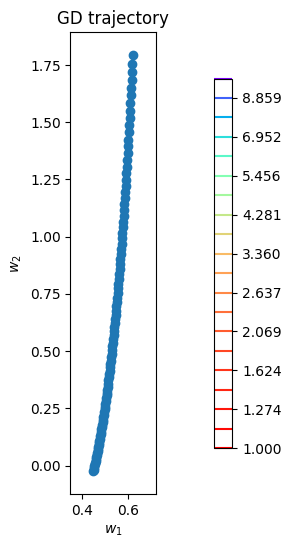

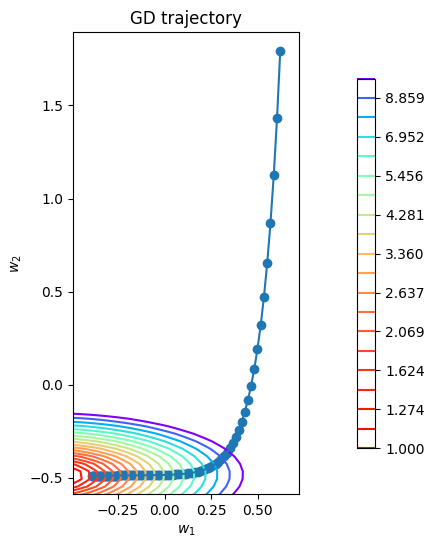

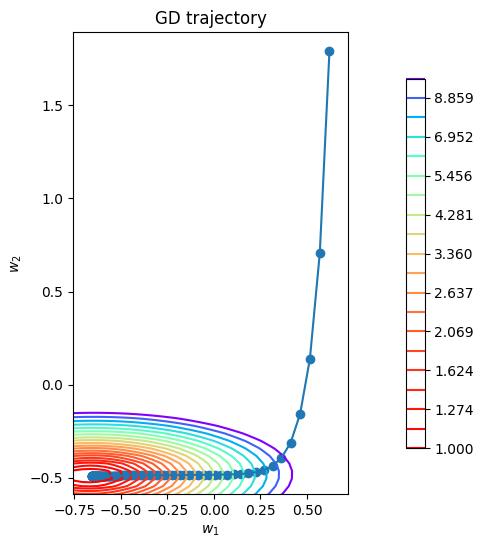

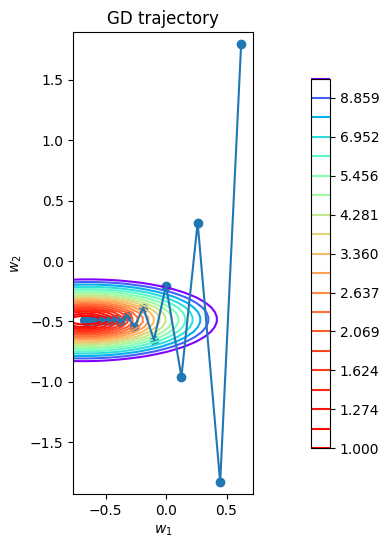

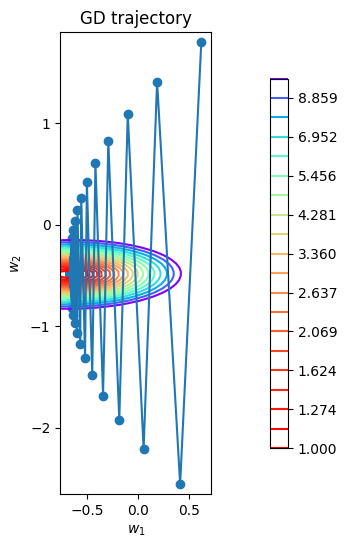

In [9]:
# -- YOUR CODE HERE -- ٩(⁎❛ᴗ❛⁎)۶
learning_rates = [0.0001, 0.001, 0.003, 0.01, 0.012]

for lr in learning_rates:
    trajectory = gradient_descent(w_init, X, y, loss, lr=lr, n_iterations=100)
    plot_gd(
        trajectory,
        X,
        y,
        loss
    )

При малом размере шага график плавный и происходит медленное движение к минимуму, из-за чего требуется большое число итераций, иначе минимум может быть недостигнут. При средних значениях траектория более быстрая и без сильных колебаний. При большом же значении шага заметны сильные колебания вокруг минимума (при дальнейшем увеличении шага может наблюдаться несходимость).

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [10]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    # -- YOUR CODE HERE -- (＠_＠)
    wt = w_init.copy()
    story = [wt.copy()]

    for _ in range(n_iterations):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        grad = loss.calc_grad(X_batch, y_batch, wt)
        wt = wt - lr * grad
        story.append(wt.copy())

    return story

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

Learning rate: 0.0001
Batch size: 1


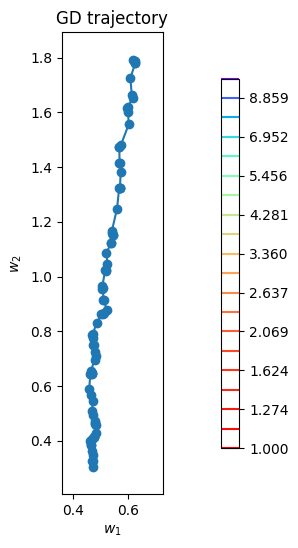

Learning rate: 0.0001
Batch size: 10


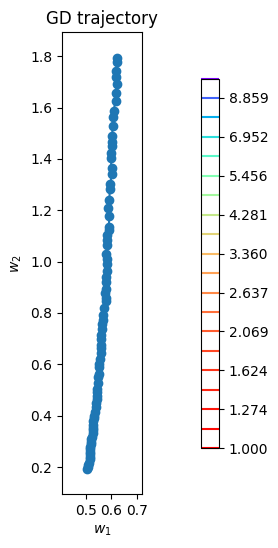

Learning rate: 0.0001
Batch size: 50


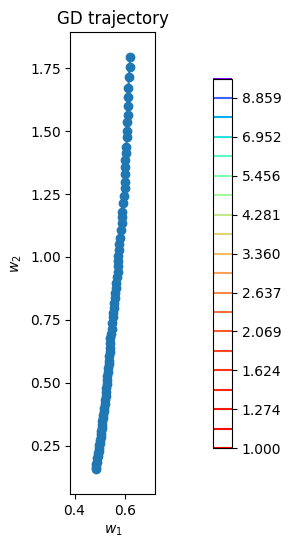

Learning rate: 0.0001
Batch size: 100


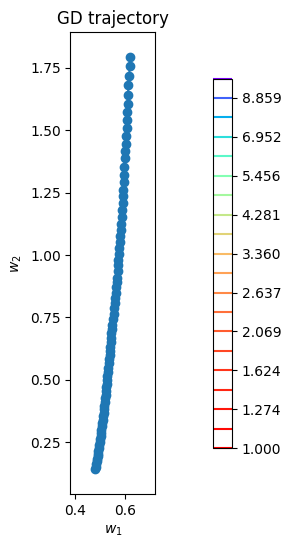

Learning rate: 0.0001
Batch size: 150


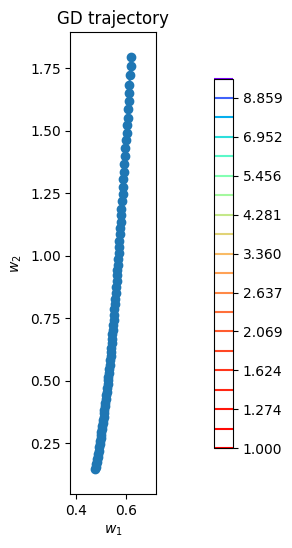

Learning rate: 0.0001
Batch size: 200


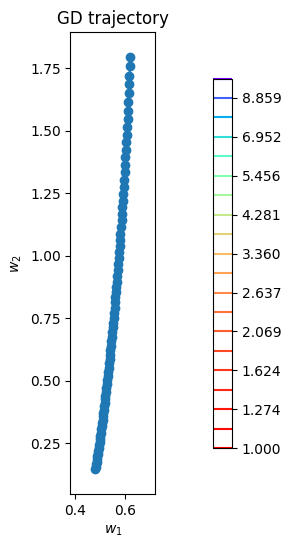

Learning rate: 0.0001
Batch size: 250


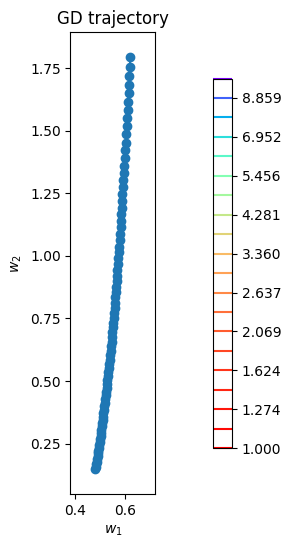

Learning rate: 0.0001
Batch size: 300


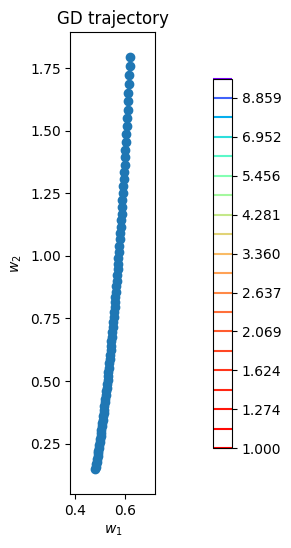

Learning rate: 0.005
Batch size: 1


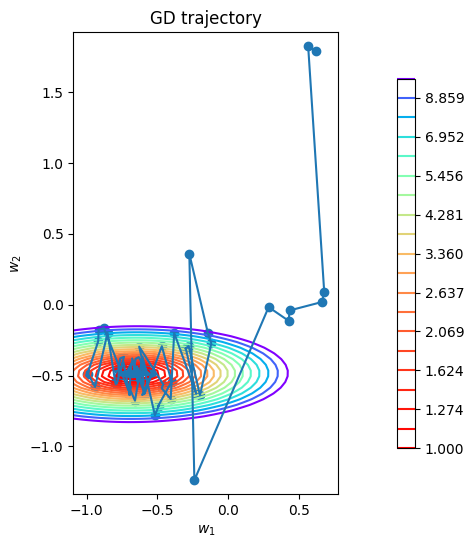

Learning rate: 0.005
Batch size: 10


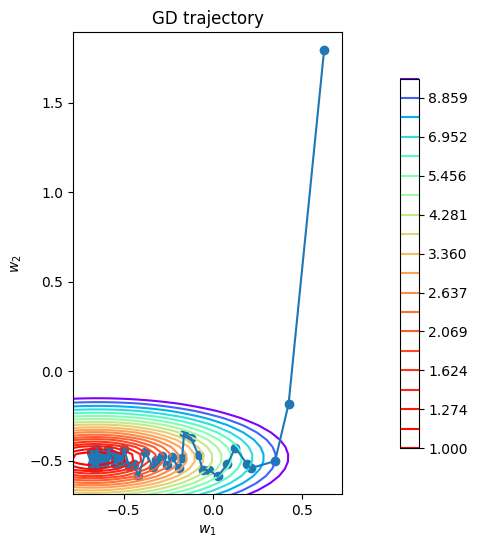

Learning rate: 0.005
Batch size: 50


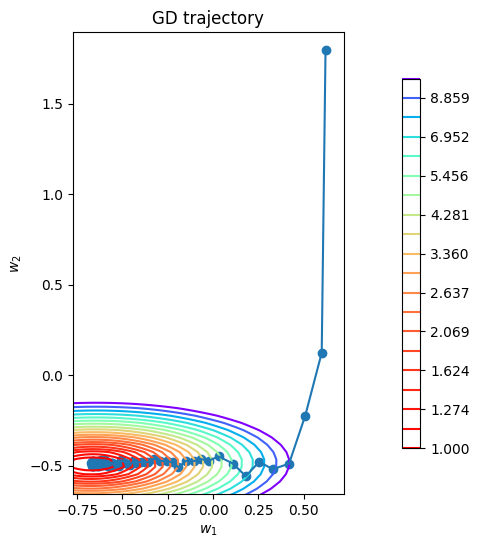

Learning rate: 0.005
Batch size: 100


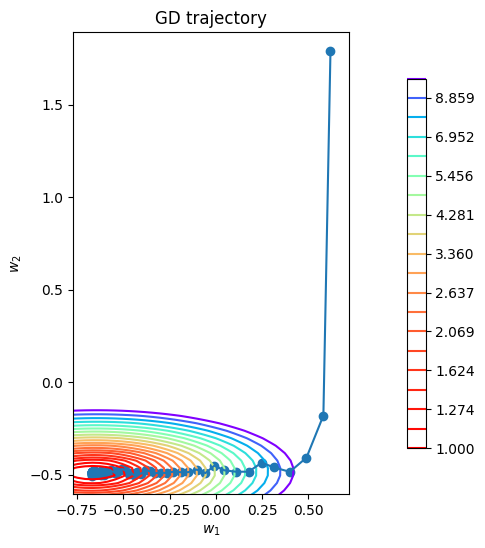

Learning rate: 0.005
Batch size: 150


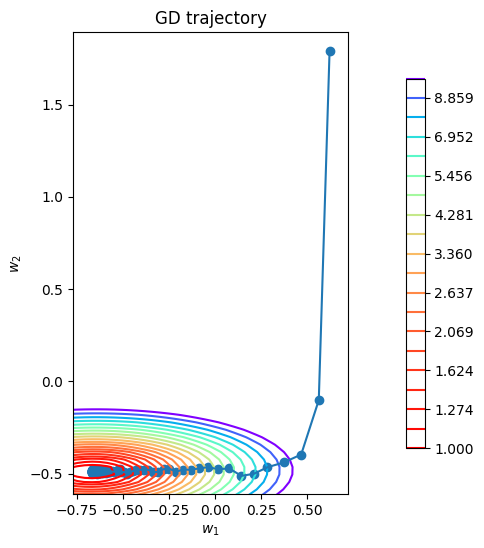

Learning rate: 0.005
Batch size: 200


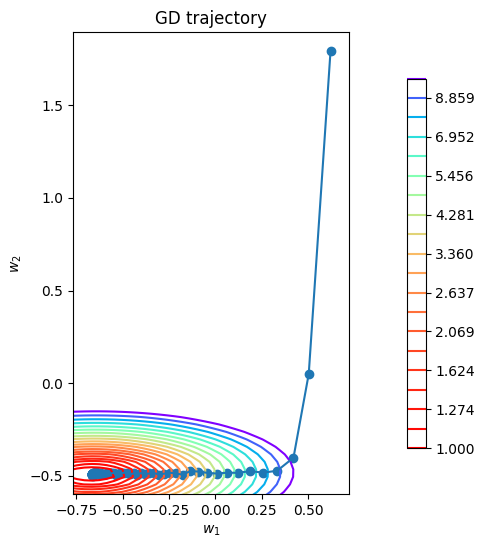

Learning rate: 0.005
Batch size: 250


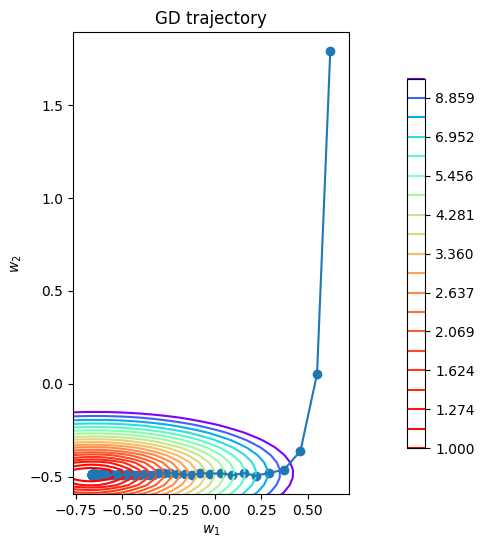

Learning rate: 0.005
Batch size: 300


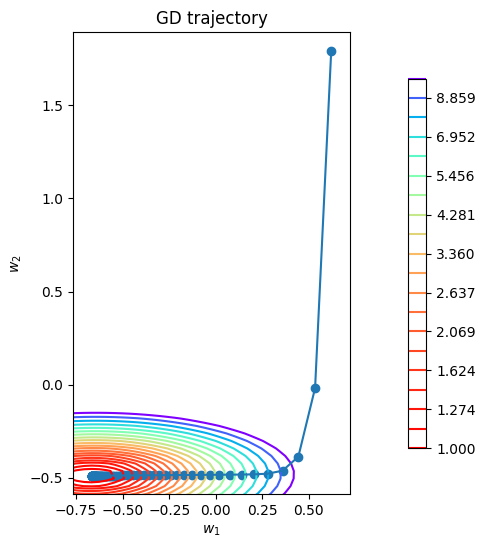

Learning rate: 0.001
Batch size: 1


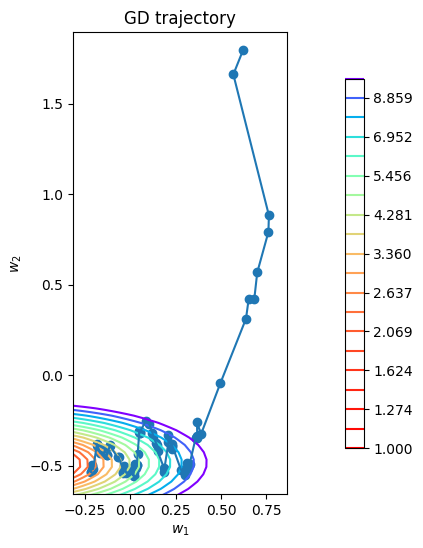

Learning rate: 0.001
Batch size: 10


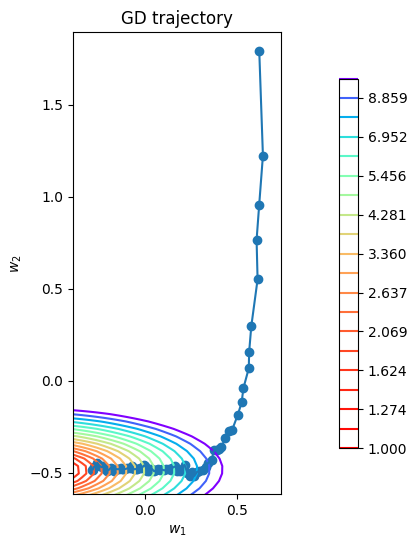

Learning rate: 0.001
Batch size: 50


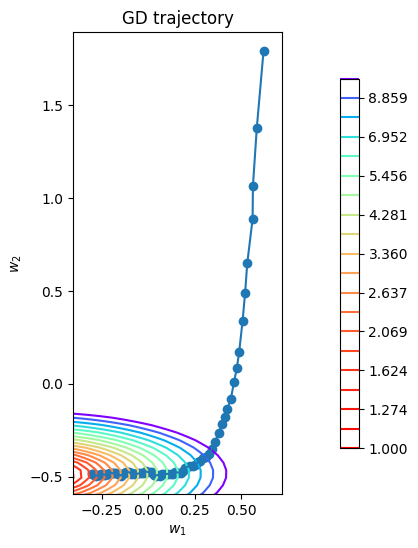

Learning rate: 0.001
Batch size: 100


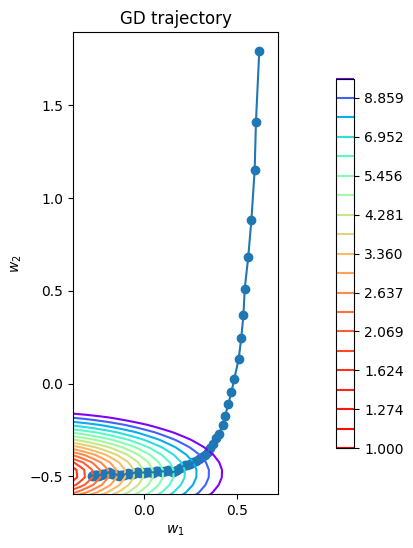

Learning rate: 0.001
Batch size: 150


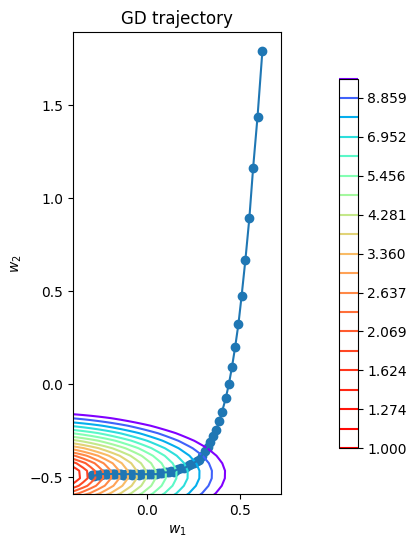

Learning rate: 0.001
Batch size: 200


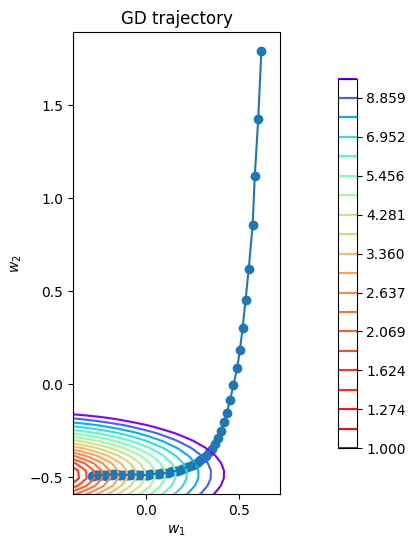

Learning rate: 0.001
Batch size: 250


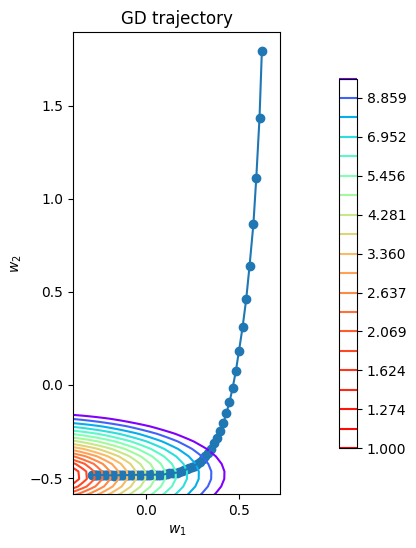

Learning rate: 0.001
Batch size: 300


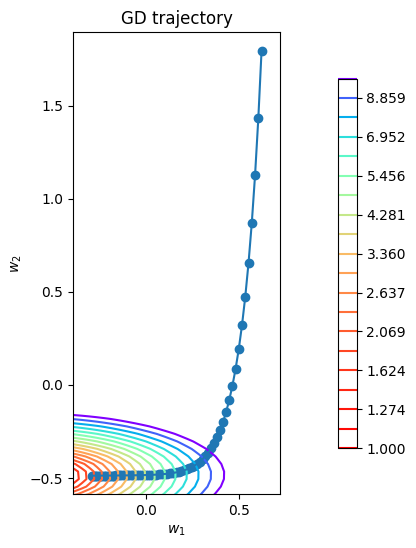

Learning rate: 0.005
Batch size: 1


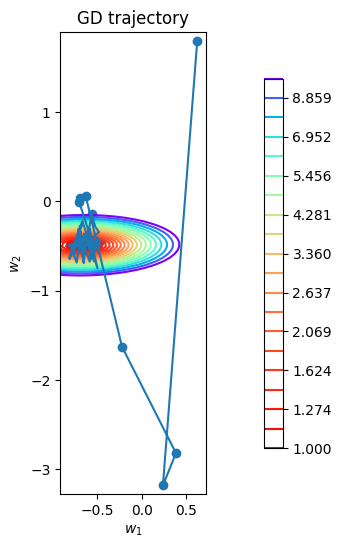

Learning rate: 0.005
Batch size: 10


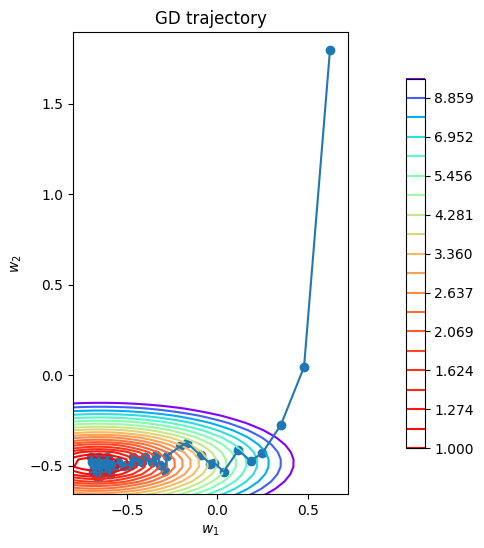

Learning rate: 0.005
Batch size: 50


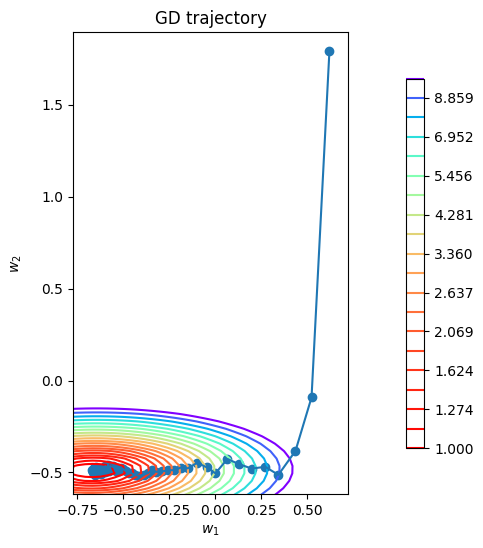

Learning rate: 0.005
Batch size: 100


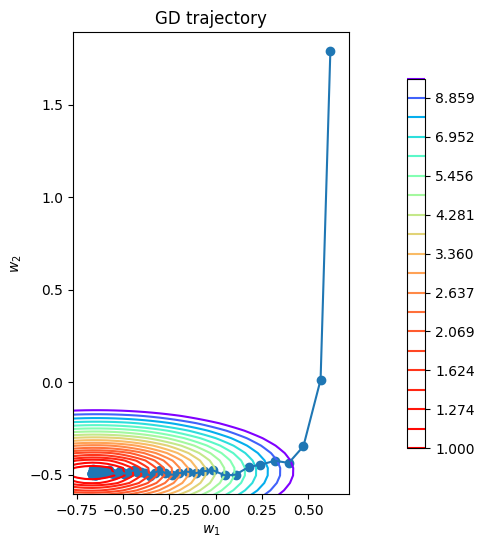

Learning rate: 0.005
Batch size: 150


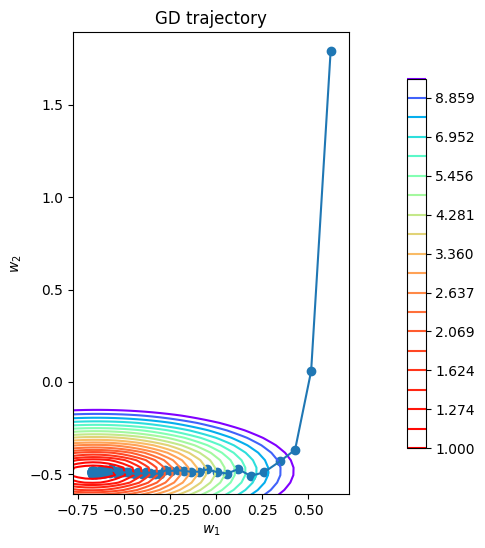

Learning rate: 0.005
Batch size: 200


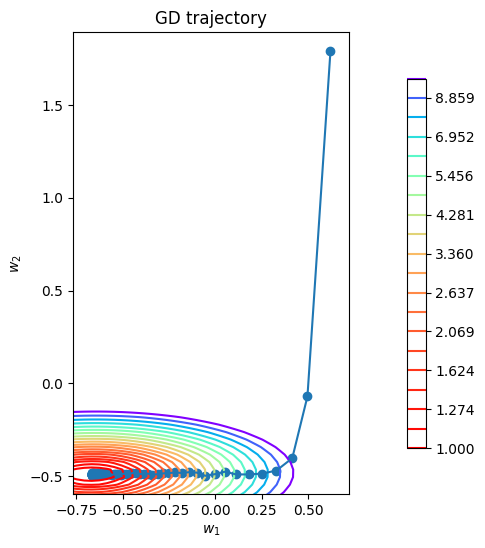

Learning rate: 0.005
Batch size: 250


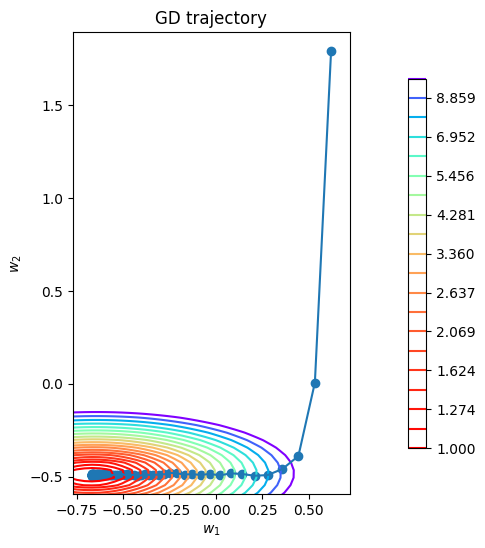

Learning rate: 0.005
Batch size: 300


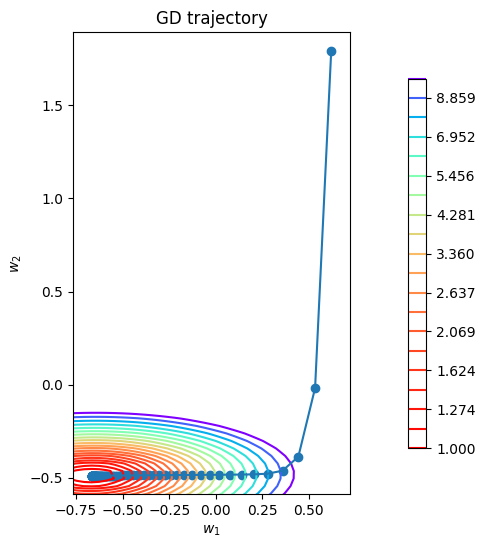

Learning rate: 0.01
Batch size: 1


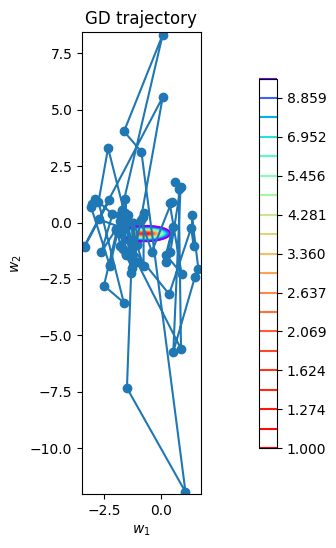

Learning rate: 0.01
Batch size: 10


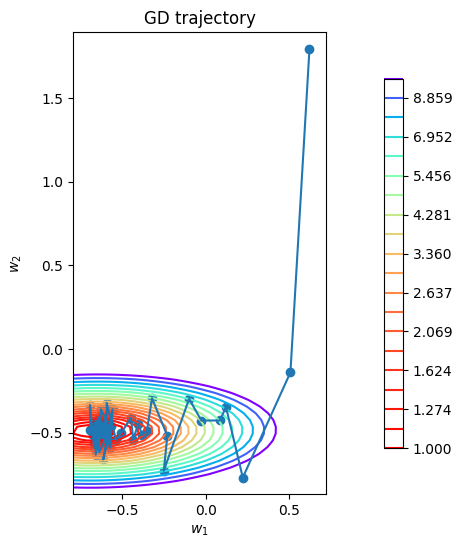

Learning rate: 0.01
Batch size: 50


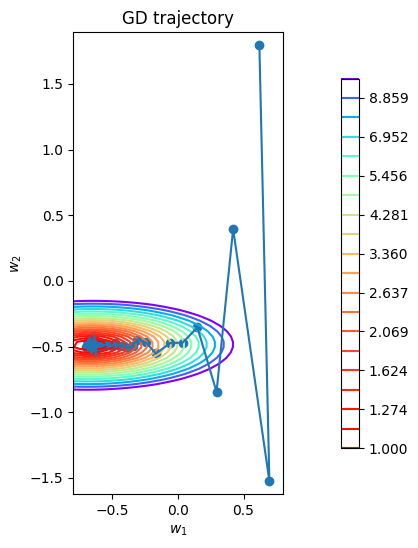

Learning rate: 0.01
Batch size: 100


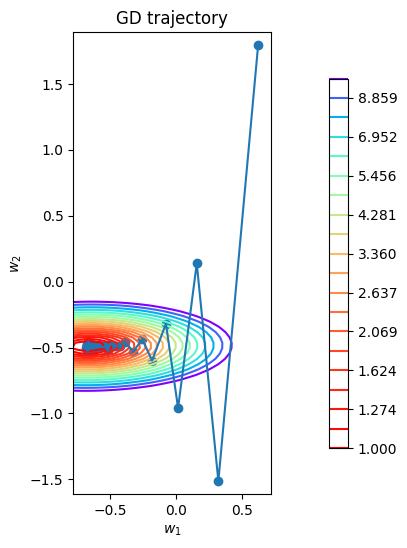

Learning rate: 0.01
Batch size: 150


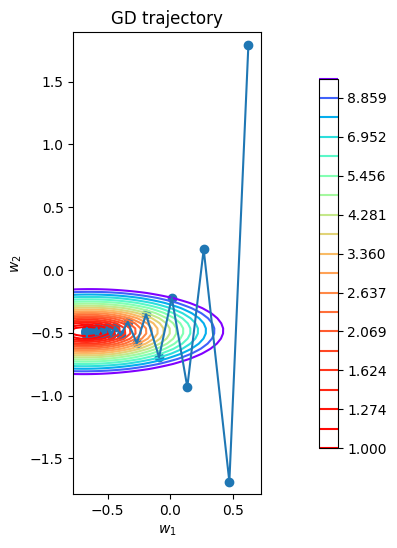

Learning rate: 0.01
Batch size: 200


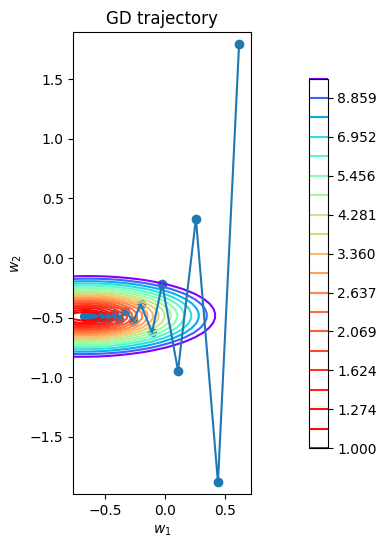

Learning rate: 0.01
Batch size: 250


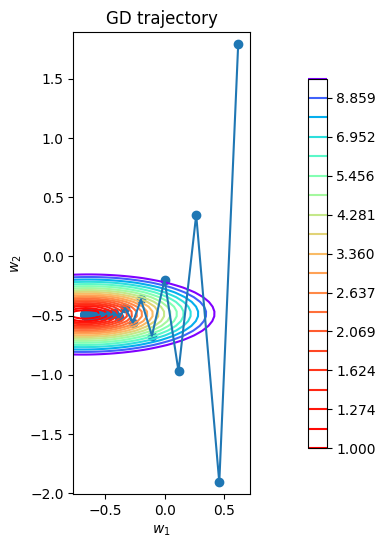

Learning rate: 0.01
Batch size: 300


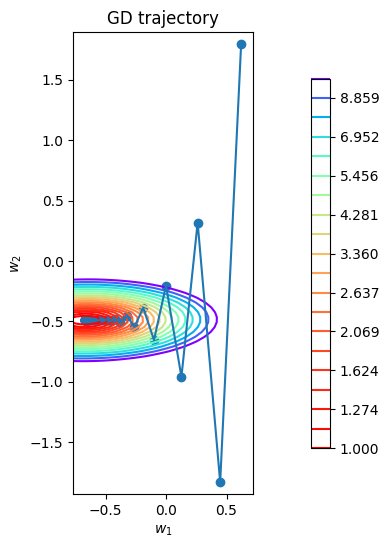

In [11]:
# -- YOUR CODE HERE -- ٩(⁎❛ᴗ❛⁎)۶
learning_rates = [0.0001, 0.005, 0.001, 0.005, 0.01]
batch_sizes = [1, 10, 50, 100, 150, 200, 250, 300]

for lr in learning_rates:
    for batch_size in batch_sizes:
      print(f"Learning rate: {lr}")
      print(f"Batch size: {batch_size}")
      story = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, 80)
      plot_gd(story, X, y, loss)

Размер шага оказывает аналогичное влияние, что и при обычном градиентном спуске. При малых значениях размера выборки наблюдается много шума и соответственно сильные колебания. При средних размерах выборки колебания меньше. При больших значениях происходит приближение к обычному градиентному спуску, траектория плавнее, но медленнее. Средние значения объединяют скорость и стабильность.
Стохастический градиентный спуск работает быстрее, но с большим шумом, так как использует только часть данных.

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [13]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: 'BaseLoss',
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция стохастического градиентного спуска с затухающим шагом.
    :param w_init: np.ndarray размера (n_features,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - начальная длина шага
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    wt = w_init.copy()
    story = [wt.copy()]
    s0 = 1
    for t in range(n_iterations):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        lr_t = lr * (s0 / (s0 + t)) ** p

        grad = loss.calc_grad(X_batch, y_batch, wt)
        wt = wt - lr_t * grad
        story.append(wt.copy())

    return story

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

p: 0.1


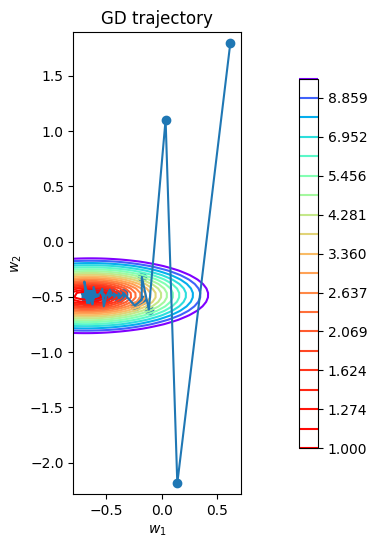

p: 0.3


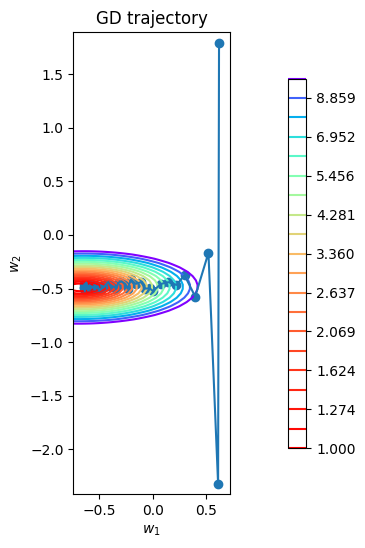

p: 0.5


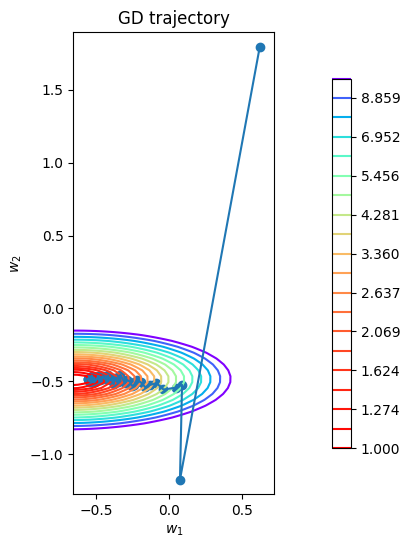

p: 1.0


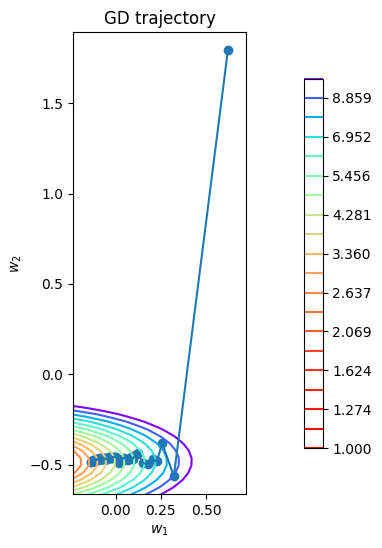

In [14]:
# -- YOUR CODE HERE -- [✖‿✖]

p_values = [0.1, 0.3, 0.5, 1.0]

for p in p_values:
      print(f"p: {p}")
      story = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, p, 80)
      plot_gd(story, X, y, loss)

Маленькие значения - быстрое приближение к минимуму в начале, много шума на более поздних итерациях.
Средние значения - уменьшение шума, но при этом относительное быстрое приближение к минимуму.
Большие значения - более плавное и точное схождение, но медленнее.

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

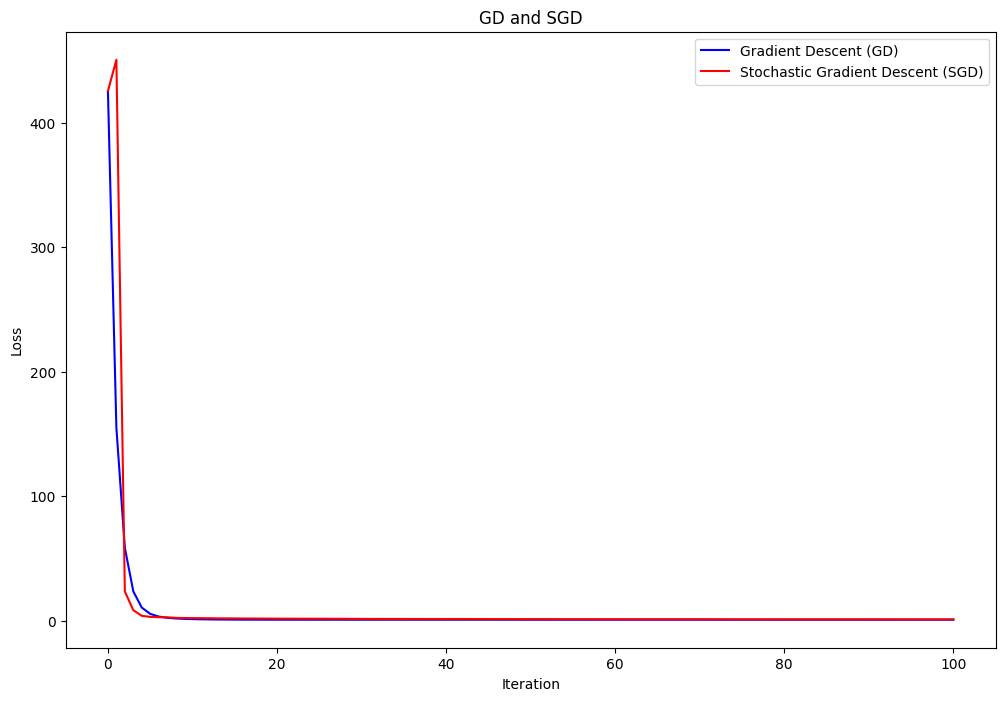

In [15]:
# -- YOUR CODE HERE -- ┌(ಠ_ಠ)┘
gd_story = gradient_descent(w_init, X, y, loss, 0.01, 100)
sgd_story = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.8, 100)

gd_losses = [loss.calc_loss(X, y, w) for w in gd_story]
sgd_losses = [loss.calc_loss(X, y, w) for w in sgd_story]

# Построение графиков
plt.figure(figsize=(12, 8))
plt.plot(gd_losses, label="Gradient Descent (GD)", color="blue")
plt.plot(sgd_losses, label="Stochastic Gradient Descent (SGD)", color="red")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("GD and SGD")
plt.legend()
plt.show()

По графику вывод сделать нельзя. Преимущество SGD заключается в произведении меньшего числа вычислений за счет увеличения шума.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [17]:
class LinearRegression:
    def __init__(self, loss: 'BaseLoss', lr: float = 0.1) -> None:
        """
        Инициализация линейной регрессии.
        :param loss: Объект подкласса BaseLoss, который умеет считать лосс и градиент.
        :param lr: Скорость обучения для градиентного спуска.
        """
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        """
        Обучение модели линейной регрессии методом градиентного спуска.
        :param X: np.ndarray размера (n_objects, n_features) - матрица объектов-признаков.
        :param y: np.ndarray размера (n_objects,) - вектор правильных ответов.
        :return: self
        """
        X = np.asarray(X)
        y = np.asarray(y)
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        n_features = X.shape[1]
        w_init = np.zeros(n_features)
        trajectory = gradient_descent(
            w_init=w_init,
            X=X,
            y=y,
            loss=self.loss,
            lr=self.lr,
            n_iterations=1000
        )
        self.w = trajectory[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Предсказание целевых значений для новых данных.
        :param X: np.ndarray размера (n_objects, n_features) - матрица объектов-признаков.
        :return: np.ndarray размера (n_objects,) - вектор предсказаний.
        """
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        return np.dot(X, self.w)

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [18]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [19]:
import pandas as pd

X_raw = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data",
    header=None,
    na_values=["?"],
)
X_raw.head()
X_raw = X_raw[~X_raw[25].isna()].reset_index()

In [20]:
y = X_raw[25]
X_raw = X_raw.drop(25, axis=1)

In [21]:
y

0      13495.0
1      16500.0
2      16500.0
3      13950.0
4      17450.0
        ...   
196    16845.0
197    19045.0
198    21485.0
199    22470.0
200    22625.0
Name: 25, Length: 201, dtype: float64

In [22]:
X_raw.head(10)

,index,0,1,2,3,4,5,6,7,8,...,15,16,17,18,19,20,21,22,23,24
0,0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
1,1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
2,2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,...,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26
3,3,2,164.0,audi,gas,std,four,sedan,fwd,front,...,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30
4,4,2,164.0,audi,gas,std,four,sedan,4wd,front,...,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22
5,5,2,NaN,audi,gas,std,two,sedan,fwd,front,...,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25
6,6,1,158.0,audi,gas,std,four,sedan,fwd,front,...,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25
7,7,1,NaN,audi,gas,std,four,wagon,fwd,front,...,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25
8,8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,...,five,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20
9,10,2,192.0,bmw,gas,std,two,sedan,rwd,front,...,four,108,mpfi,3.50,2.80,8.8,101.0,5800.0,23,29


**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_raw.columns = X_raw.columns.astype(str)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=173
)

numeric_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_raw.select_dtypes(include=['object']).columns

imputer_num = SimpleImputer(strategy='median')
X_train_num = imputer_num.fit_transform(X_train_raw[numeric_cols])
X_test_num = imputer_num.transform(X_test_raw[numeric_cols])

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

imputer_cat = SimpleImputer(strategy='most_frequent')
X_train_cat = imputer_cat.fit_transform(X_train_raw[categorical_cols])
X_test_cat = imputer_cat.transform(X_test_raw[categorical_cols])

encoder = OneHotEncoder(handle_unknown='ignore')
X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_test_cat_encoded = encoder.transform(X_test_cat)

cat_col_names = [f"cat_{i}" for i in range(len(categorical_cols))]
feature_names = encoder.get_feature_names_out(cat_col_names)

X_train = pd.DataFrame(
    data=X_train_num_scaled,
    columns=[f"num_{i}" for i in range(len(numeric_cols))]
).join(
    pd.DataFrame(
        data=X_train_cat_encoded.toarray(),
        columns=feature_names
    )
)

X_test = pd.DataFrame(
    data=X_test_num_scaled,
    columns=[f"num_{i}" for i in range(len(numeric_cols))]
).join(
    pd.DataFrame(
        data=X_test_cat_encoded.toarray(),
        columns=feature_names
    )
)

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [263]:
# -- YOUR CODE HERE -- (ﾉ´ з `)ノ
linear_regression.fit(X_train, y_train)

y_pred = linear_regression.predict(X_test)
mse = np.mean((y_pred - y_test) ** 2)
print(f"MSE на тестовой выборке: {mse:.2f}")

MSE на тестовой выборке: 5943480.10


**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [265]:
from sklearn.metrics import mean_squared_error

# -- YOUR CODE HERE -- ( ⚆ ω ⚆)
linear_regression.fit(X_train, y_train)

y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"MSE на обучающей выборке: {train_mse:.2f}")
print(f"MSE на тестовой выборке: {test_mse:.2f}")

MSE на обучающей выборке: 2133069.25
MSE на тестовой выборке: 5943480.10


Наша модель переобучилась (а если state=72,например, то нет, а на 113 да). 
Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [267]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """

        predict = np.dot(X, w)
        loss = np.mean((predict - y) ** 2)

        w_without_bias = w[:-1]
        reg = self.coef * np.sum(w_without_bias ** 2)

        return loss + reg

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        predict = np.dot(X, w)
        grad = (2 / l) * np.dot(X.T, (predict - y))

        reg_add = 2 * self.coef * w
        reg_add[-1] = 0
        return grad + reg_add

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [273]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [269]:
train_mse

2133069.253779692

In [271]:
test_mse

5943480.103034698

In [277]:
# -- YOUR CODE HERE -- (＠_＠)
min_train_mse = train_mse
min_test_mse = test_mse
best_coef = 0

for coef in np.logspace(-3, 3, num=100):
    lr = 0.1 / (1 + coef)
    model = LinearRegression(loss=MSEL2Loss(coef), lr=lr)
    try:
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
            
        train_mse_1 = mean_squared_error(y_train, y_train_pred)
        test_mse_1 = mean_squared_error(y_test, y_test_pred)
        
        
        if (test_mse_1 < min_test_mse):
            min_train_mse = train_mse_1
            min_test_mse = test_mse_1
            best_coef = coef
            
    except Exception as e:
        print(f"Ошибка при coef={coef:.3f}: {str(e)}")
        continue
        
print("Наилучшие результаты:")
print(f"MSE на обучающей выборке: {min_train_mse:.2f}")
print(f"MSE на тестовой выборке: {min_test_mse:.2f}")
print(f"Коэффициент {best_coef}")
print(f"Улучшение не тренировочной выборке: {train_mse - min_train_mse}")
print(f"Улучшение не тестовой выборке: {test_mse - min_test_mse}")

Наилучшие результаты:
MSE на обучающей выборке: 2278946.57
MSE на тестовой выборке: 5870640.23
Коэффициент 0.0023101297000831605
Улучшение не тренировочной выборке: -145877.3159445771
Улучшение не тестовой выборке: 72839.87761811726


В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [24]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        residuals = np.dot(X, w) - y
        abs_res = np.abs(residuals)
        return np.mean(np.where(abs_res < self.eps, 0.5 * abs_res ** 2, self.eps * (abs_res - 0.5 * self.eps)))

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        residuals = np.dot(X, w) - y
        abs_res = np.abs(residuals)
        z = np.where(abs_res < self.eps, residuals, self.eps * np.sign(residuals))
        return np.dot(X.T, z) / l

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [289]:
# -- YOUR CODE HERE -- # (⌐■_■)
min_train_mse = np.inf
min_test_mse = np.inf

train_mse_old = 2133069.25
test_mse_old = 5943480.10

best_coef = 0

for coef in np.logspace(-3, 3, num=100):
    model = LinearRegression(loss=HuberLoss(coef))
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse_1 = mean_squared_error(y_train, y_train_pred)
    test_mse_1 = mean_squared_error(y_test, y_test_pred)

    if (test_mse_1 < min_test_mse):
        min_train_mse = train_mse_1
        min_test_mse = test_mse_1
        best_coef = coef
print("Наилучшие результаты:")
print(f"MSE на обучающей выборке: {min_train_mse:.2f}")
print(f"MSE на тестовой выборке: {min_test_mse:.2f}")
print(f"Коэффициент {best_coef}")
print(f"Улучшение не тренировочной выборке: {train_mse_old - min_train_mse}")
print(f"Улучшение не тестовой выборке: {test_mse_old - min_test_mse}")

Наилучшие результаты:
MSE на обучающей выборке: 4366299.51
MSE на тестовой выборке: 6928021.27
Коэффициент 1000.0
Улучшение не тренировочной выборке: -2233230.2562787803
Улучшение не тестовой выборке: -984541.174947639


Для нас очевидно, что максимизировать MSE для модели, обученной на другой функции ошибок - довольно бессмысленно. Предсказуемо, что достичь MSE, сопостовимого с MSE модели, обученного на этой функции ошибок у нас не вышло. Попробуем зафиксировать параметр-лямбду и сравнить модели по различным иным функциям ошибок

In [42]:
from sklearn.metrics import median_absolute_error

from sklearn.metrics import mean_absolute_percentage_error

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

from sklearn.metrics import max_error

from sklearn.metrics import mean_squared_log_error

from sklearn.metrics import explained_variance_score

def quantile_loss(y_true, y_pred, alpha=0.5):
    errors = y_true - y_pred
    return np.mean(np.maximum(alpha * errors, (alpha - 1) * errors))

from sklearn.metrics import mean_tweedie_deviance

def rae(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)))
    return numerator / denominator

modelHuber = LinearRegression(loss=HuberLoss(1337))
modelMSE = LinearRegression(MSELoss())
modelHuber.fit(X_train, y_train)
modelMSE.fit(X_train, y_train)

y_predHuber = modelHuber.predict(X_test)

y_predMSE = modelMSE.predict(X_test)

medaeHuber = median_absolute_error(y_test, y_predHuber)
medaeMSE = median_absolute_error(y_test, y_predMSE)

print(f"MedAE для модели, обученной на функции потерь Хубера: {medaeHuber:.5f}")
print(f"MedAE для модели, обученной на функции потерь MSE: {medaeMSE:.5f}")
print()

mapeHuber = mean_absolute_percentage_error(y_test, y_predHuber)
mapeMSE = mean_absolute_percentage_error(y_test, y_predMSE)

print(f"MAPE для модели, обученной на функции потерь Хубера: {mapeHuber:.5f}")
print(f"MAPE для модели, обученной на функции потерь MSE: {mapeMSE:.5f}")
print()

smapeHuber = smape(y_test, y_predHuber)
smapeMSE = smape(y_test, y_predMSE)

print(f"SMAPE для модели, обученной на функции потерь Хубера: {smapeHuber:.5f}")
print(f"SMAPE для модели, обученной на функции потерь MSE: {smapeMSE:.5f}")
print()

max_errHuber = max_error(y_test, y_predHuber)
max_errMSE = max_error(y_test, y_predMSE)

print(f"Максимальная ошибка для модели, обученной на функции потерь Хубера: {smapeHuber:.5f}")
print(f"Максимальная ошибка для модели, обученной на функции потерь MSE: {smapeMSE:.5f}")
print()

msleHuber = mean_squared_log_error(y_test, y_predHuber)
msleMSE = mean_squared_log_error(y_test, y_predMSE)

print(f"MSLE для модели, обученной на функции потерь Хубера: {msleHuber:.5f}")
print(f"MSLE для модели, обученной на функции потерь MSE: {msleMSE:.5f}")
print()

evsHuber = explained_variance_score(y_test, y_predHuber)
evsMSE = explained_variance_score(y_test, y_predMSE)

print(f"EVS для модели, обученной на функции потерь Хубера: {evsHuber:.5f}")
print(f"EVS для модели, обученной на функции потерь MSE: {evsMSE:.5f}")
print()

qlHuber = quantile_loss(y_test, y_predHuber, alpha=0.5)
qlMSE = quantile_loss(y_test, y_predMSE, alpha=0.5)

print(f"Quantile loss для модели, обученной на функции потерь Хубера: {qlHuber:.5f}")
print(f"Quantile loss для модели, обученной на функции потерь MSE: {qlMSE:.5f}")
print()

devianceHuber = mean_tweedie_deviance(y_test, y_predHuber, power=1.5)
devianceMSE = mean_tweedie_deviance(y_test, y_predMSE, power=1.5)

print(f"Deviance для модели, обученной на функции потерь Хубера: {devianceHuber:.5f}")
print(f"Deviance для модели, обученной на функции потерь MSE: {devianceMSE:.5f}")
print()

raeHuber = rae(y_test, y_predHuber)
raeMSE = rae(y_test, y_predMSE)

print(f"RAE для модели, обученной на функции потерь Хубера: {raeHuber:.5f}")
print(f"RAE для модели, обученной на функции потерь MSE: {raeMSE:.5f}")
print()

MedAE для модели, обученной на функции потерь Хубера: 1113.19381
MedAE для модели, обученной на функции потерь MSE: 1292.54514

MAPE для модели, обученной на функции потерь Хубера: 0.14053
MAPE для модели, обученной на функции потерь MSE: 0.13494

SMAPE для модели, обученной на функции потерь Хубера: 13.23505
SMAPE для модели, обученной на функции потерь MSE: 13.29587

Максимальная ошибка для модели, обученной на функции потерь Хубера: 13.23505
Максимальная ошибка для модели, обученной на функции потерь MSE: 13.29587

MSLE для модели, обученной на функции потерь Хубера: 0.03398
MSLE для модели, обученной на функции потерь MSE: 0.03070

EVS для модели, обученной на функции потерь Хубера: 0.90810
EVS для модели, обученной на функции потерь MSE: 0.91432

Quantile loss для модели, обученной на функции потерь Хубера: 890.59956
Quantile loss для модели, обученной на функции потерь MSE: 894.00388

Deviance для модели, обученной на функции потерь Хубера: 3.52433
Deviance для модели, обученной 

Более детальный анализ показывает, что некоторые типы ошибок при обучении с Huber ниже. Это ещё раз напоминает нам о том, что нет хороших и плохих функций потерь, дело в том, какой цели мы хотим достичь

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

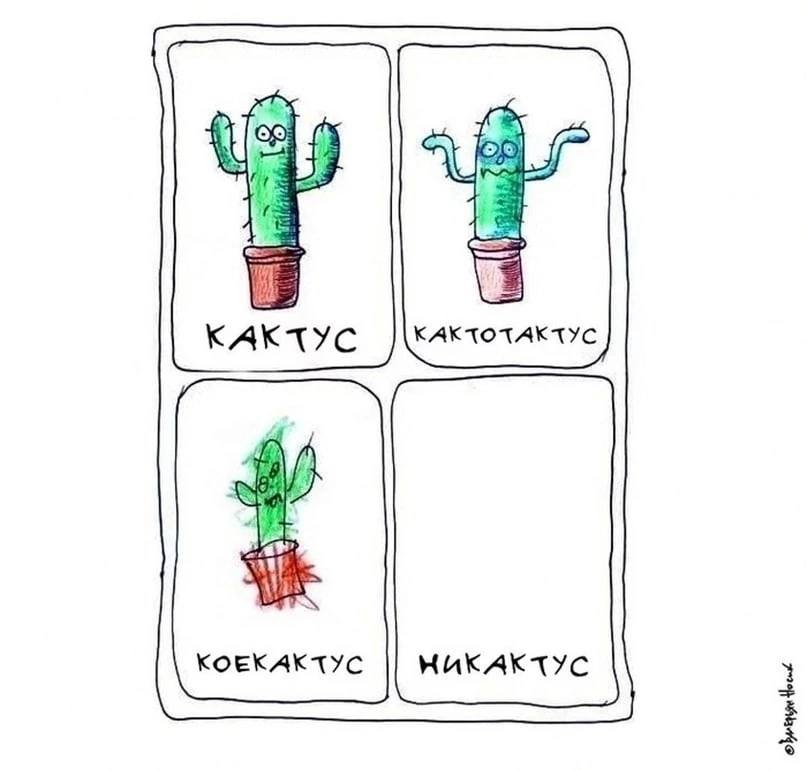

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

Iter 0: Loss=10.02, Temp=100.0
Iter 100: Loss=0.81, Temp=36.6
Iter 300: Loss=0.79, Temp=4.9
Iter 600: Loss=0.07, Temp=0.2
Iter 700: Loss=0.09, Temp=0.1


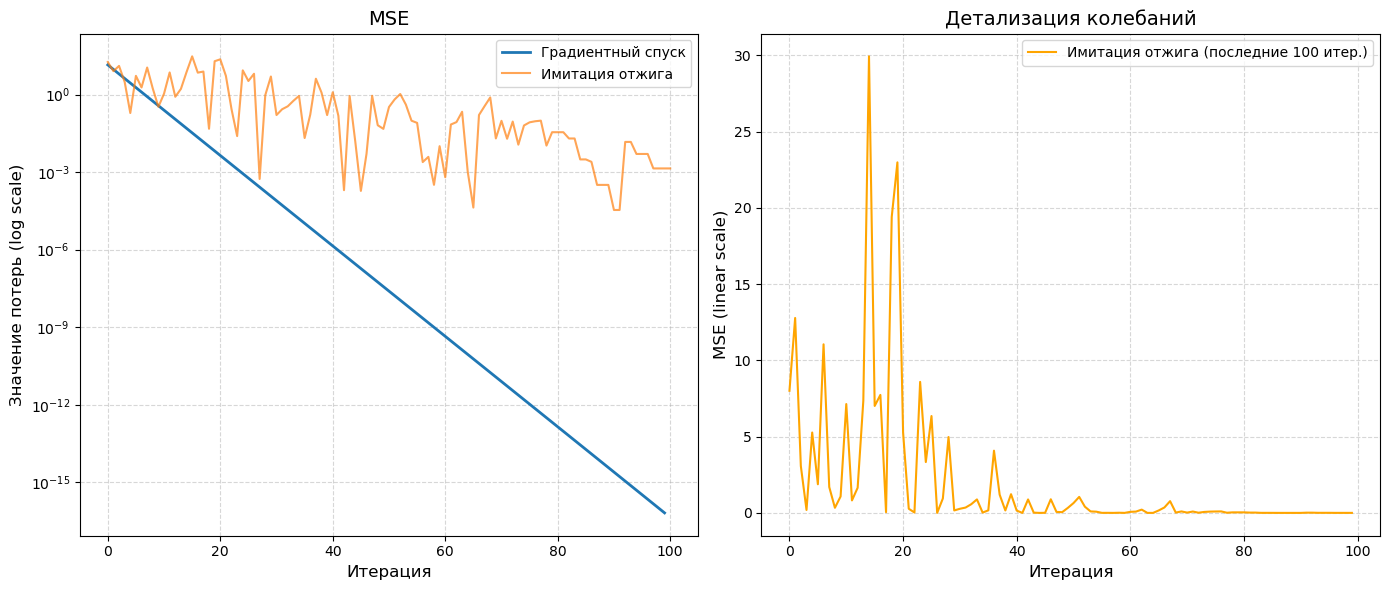

In [47]:
import numpy as np
from scipy.stats import t
import matplotlib.pyplot as plt

class MSELoss:
    def calc_loss(self, X, y, w):
        return np.mean(X @ w - y)**2
    
    def calc_grad(self, X, y, w):
        return 2 * X.T @ (X @ w - y) / X.shape[0]

class LinearRegression:
    def __init__(self, loss, lr=0.01, max_iter=1000):
        self.loss = loss
        self.lr = lr
        self.max_iter = max_iter
        self.loss_history = []

    def fit(self, X, y):
        X = np.hstack([X, np.ones((X.shape[0], 1))])
        self.w = np.random.uniform(-2, 2, X.shape[1])
        for _ in range(self.max_iter):
            grad = self.loss.calc_grad(X, y, self.w)
            self.w -= self.lr * grad
            self.loss_history.append(self.loss.calc_loss(X, y, self.w))
        return self

class SimulatedAnnealing:
    def __init__(self, loss, temp_init=100.0, alpha=0.99, 
                 max_iter=1000, step_scale=0.5):
        self.loss = loss
        self.temp = temp_init
        self.alpha = alpha
        self.max_iter = max_iter
        self.step_scale = step_scale
        self.loss_history = []
    
    def fit(self, X, y):
        X = np.hstack([X, np.ones((X.shape[0], 1))])
        self.w = np.random.uniform(-2, 2, X.shape[1])
        current_loss = self.loss.calc_loss(X, y, self.w)
        self.loss_history.append(current_loss)
        
        for i in range(self.max_iter):
            new_w = self.w + self.step_scale * t.rvs(3, size=self.w.shape)
            new_loss = self.loss.calc_loss(X, y, new_w)
            delta = new_loss - current_loss
            
            if delta < 0 or np.random.rand() < np.exp(-delta / self.temp):
                self.w = new_w
                current_loss = new_loss
                if i % 100 == 0:
                    print(f"Iter {i}: Loss={current_loss:.2f}, Temp={self.temp:.1f}")
            
            self.temp *= self.alpha
            self.loss_history.append(current_loss)
        return self

np.random.seed(42)
X = np.random.randn(500, 2)
true_w = np.array([2.5, -1.8, 3.0])
y = X.dot(true_w[:-1]) + true_w[-1] + np.random.randn(500) * 0.5
y[::50] += 20 * np.random.randn(10)

configs = {
    "MSE": {"loss": MSELoss(), "gd_lr": 0.01},
}

results = {}

for name, cfg in configs.items():
    model_gd = LinearRegression(loss=cfg["loss"], lr=cfg["gd_lr"], max_iter=1000)
    model_gd.fit(X, y)
    
    model_sa = SimulatedAnnealing(loss=cfg["loss"], 
                                temp_init=100, 
                                alpha=0.99,
                                step_scale=1.0,
                                max_iter=1000)
    model_sa.fit(X, y)
    
    results[name] = {
        "GD": model_gd.loss_history[::10],
        "SA": model_sa.loss_history[::10]
    }

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(results["MSE"]["GD"], label='Градиентный спуск', linewidth=2)
plt.plot(results["MSE"]["SA"], label='Имитация отжига', alpha=0.7)
plt.title('MSE', fontsize=14)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('Значение потерь (log scale)', fontsize=12)
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results["MSE"]["SA"][-100:], label='Имитация отжига (последние 100 итер.)', color='orange')
plt.title('Детализация колебаний', fontsize=14)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('MSE (linear scale)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Iter 300: Loss=150849604.93, Temp=4.9
Iter 500: Loss=142291705.00, Temp=0.7
Iter 700: Loss=133627682.92, Temp=0.1


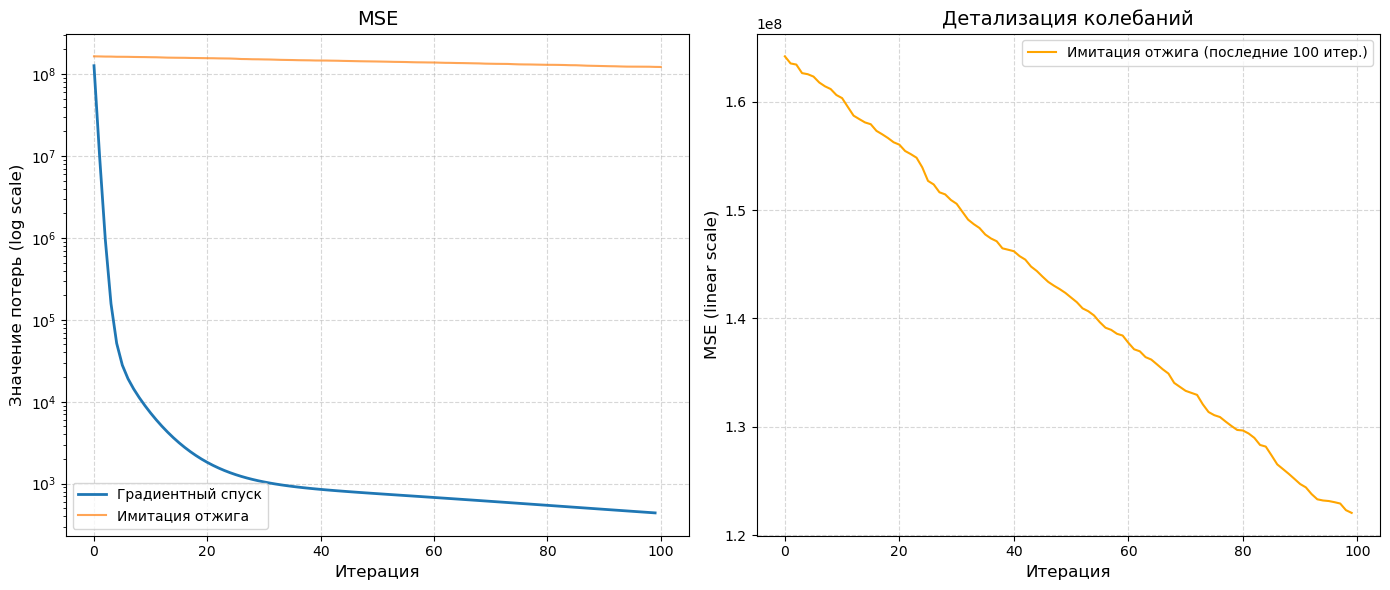

In [53]:
X = X_train
y = y_train

configs = {
    "MSE": {"loss": MSELoss(), "gd_lr": 0.01},
}

results = {}

for name, cfg in configs.items():
    model_gd = LinearRegression(loss=cfg["loss"], lr=cfg["gd_lr"], max_iter=1000)
    model_gd.fit(X, y)
    
    model_sa = SimulatedAnnealing(loss=cfg["loss"], 
                                temp_init=100, 
                                alpha=0.99,
                                step_scale=1.0,
                                max_iter=1000)
    model_sa.fit(X, y)
    
    results[name] = {
        "GD": model_gd.loss_history[::10],
        "SA": model_sa.loss_history[::10]
    }

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(results["MSE"]["GD"], label='Градиентный спуск', linewidth=2)
plt.plot(results["MSE"]["SA"], label='Имитация отжига', alpha=0.7)
plt.title('MSE', fontsize=14)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('Значение потерь (log scale)', fontsize=12)
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results["MSE"]["SA"][-100:], label='Имитация отжига (последние 100 итер.)', color='orange')
plt.title('Детализация колебаний', fontsize=14)
plt.xlabel('Итерация', fontsize=12)
plt.ylabel('MSE (linear scale)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()